# 공급망 배송 지연 리스크 분석
## STEP 1 — 탐색적 데이터 분석 (EDA)

**분석 목표**  
배송 지연이 어떤 조건에서 많이 발생하는지 탐색하고, 모델링 단계에서 사용할 수 있는 변수와 제거해야 할 누수 변수를 구분한다.

**주의점**  
EDA에서는 `Days for shipping (real)`처럼 타겟과 강하게 연결되는 사후 정보도 함께 확인한다. 다만 이 변수는 배송 완료 후에야 알 수 있으므로, 모델링 피처가 아니라 **데이터 누수 후보**로 해석한다.

**진행 순서**  
1. 데이터 불러오기 및 기본 확인  
2. 결측치 확인  
3. 타겟 변수 분포 확인  
4. 주요 변수별 지연율 분석  
5. 수치형 변수 분포 확인  
6. 상관관계 확인  
7. EDA 요약 및 다음 단계 정리


---
## 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import matplotlib.font_manager as fm
import os

warnings.filterwarnings('ignore')

# 그래프 기본 스타일 설정
sns.set_style('whitegrid')

# 한글 폰트 설정
font_regular = 'C:/Windows/Fonts/malgun.ttf'     # 맑은 고딕 Regular
font_bold = 'C:/Windows/Fonts/malgunbd.ttf'      # 맑은 고딕 Bold

# 폰트 파일 등록
if os.path.exists(font_regular):
    fm.fontManager.addfont(font_regular)

if os.path.exists(font_bold):
    fm.fontManager.addfont(font_bold)

# matplotlib 전체 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('라이브러리 및 한글 폰트 설정 완료')
print('현재 font.family:', plt.rcParams['font.family'])

라이브러리 및 한글 폰트 설정 완료
현재 font.family: ['Malgun Gothic']


---
## 1. 데이터 불러오기 및 기본 확인

In [2]:
# CSV 파일 불러오기 (인코딩: latin1 — 특수문자 포함된 파일에 자주 사용)
from pathlib import Path

path_candidates = [
    Path('../data/raw/DataCoSupplyChainDataset.csv'),
    Path('data/raw/DataCoSupplyChainDataset.csv'),
    Path('DataCoSupplyChainDataset.csv'),
    Path('/mnt/data/DataCoSupplyChainDataset.csv'),
]

for path in path_candidates:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError('DataCoSupplyChainDataset.csv 파일을 찾을 수 없습니다. data/raw 폴더에 원본 데이터를 넣어주세요.')

df = pd.read_csv(data_path, encoding='latin1')

print(f'데이터 경로: {data_path}')
print(f'행 수: {len(df):,}개')
print(f'컬럼 수: {len(df.columns)}개')
print()
print('상위 3개 행 미리보기:')
df.head(3)


데이터 경로: ..\data\raw\DataCoSupplyChainDataset.csv
행 수: 180,519개
컬럼 수: 53개

상위 3개 행 미리보기:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [3]:
# 컬럼 목록 전체 확인
print('전체 컬럼 목록:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

전체 컬럼 목록:
   1. Type
   2. Days for shipping (real)
   3. Days for shipment (scheduled)
   4. Benefit per order
   5. Sales per customer
   6. Delivery Status
   7. Late_delivery_risk
   8. Category Id
   9. Category Name
  10. Customer City
  11. Customer Country
  12. Customer Email
  13. Customer Fname
  14. Customer Id
  15. Customer Lname
  16. Customer Password
  17. Customer Segment
  18. Customer State
  19. Customer Street
  20. Customer Zipcode
  21. Department Id
  22. Department Name
  23. Latitude
  24. Longitude
  25. Market
  26. Order City
  27. Order Country
  28. Order Customer Id
  29. order date (DateOrders)
  30. Order Id
  31. Order Item Cardprod Id
  32. Order Item Discount
  33. Order Item Discount Rate
  34. Order Item Id
  35. Order Item Product Price
  36. Order Item Profit Ratio
  37. Order Item Quantity
  38. Sales
  39. Order Item Total
  40. Order Profit Per Order
  41. Order Region
  42. Order State
  43. Order Status
  44. Order Zipcode
  45. Product Ca

In [4]:
# 데이터 타입 및 기본 통계 확인
print('=== 데이터 타입 ===')  
print(df.dtypes)
print()
print('=== 수치형 변수 기본 통계 ===')
df.describe()

=== 데이터 타입 ===
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
M

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


---
## 2. 결측치 확인

In [5]:
# 결측치 개수 및 비율 계산
missing_count = df.isnull().sum()
missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing_count,
    '결측 비율(%)': missing_ratio
})

# 결측치가 있는 컬럼만 출력
missing_df = missing_df[missing_df['결측치 수'] > 0].sort_values('결측치 수', ascending=False)

print('결측치가 있는 컬럼:')
print(missing_df)
print()
print('처리 방향:')
print('  - Product Description: 결측 100% → 분석에서 제외')
print('  - Order Zipcode: 결측 86% → 분석에서 제외')
print('  - Customer Lname, Customer Zipcode: 결측 미미 → 개인정보라 어차피 미사용')

결측치가 있는 컬럼:
                      결측치 수  결측 비율(%)
Product Description  180519    100.00
Order Zipcode        155679     86.24
Customer Lname            8      0.00
Customer Zipcode          3      0.00

처리 방향:
  - Product Description: 결측 100% → 분석에서 제외
  - Order Zipcode: 결측 86% → 분석에서 제외
  - Customer Lname, Customer Zipcode: 결측 미미 → 개인정보라 어차피 미사용


---
## 3. 타겟 변수 분포 확인

> **타겟 변수**: `Late_delivery_risk`  
> - 1 = 배송 지연  
> - 0 = 정상 배송

In [6]:
# 타겟 변수 분포 수치 확인
target_counts = df['Late_delivery_risk'].value_counts()
target_ratio = df['Late_delivery_risk'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    '건수': target_counts,
    '비율(%)': target_ratio.round(1)
})
target_summary.index = ['지연(1)', '정상(0)']
print(target_summary)

print()
print('배송 상태 세부 분포:')
print(df['Delivery Status'].value_counts())

          건수  비율(%)
지연(1)  98977   54.8
정상(0)  81542   45.2

배송 상태 세부 분포:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


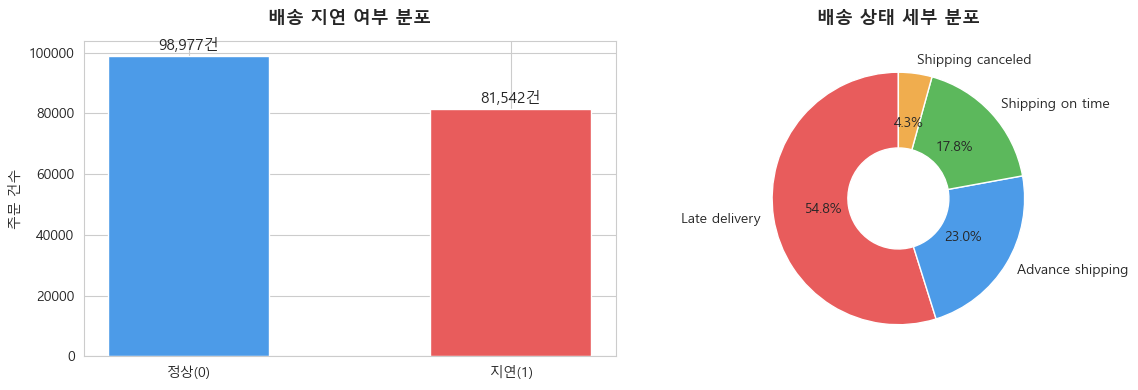


[해석]
전체 주문의 54.8%가 지연 — 절반 이상이 지연되고 있어 개선이 시급한 상황


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 지연 여부 (0/1) 막대 그래프
colors = ['#4C9BE8', '#E85C5C']
bars = axes[0].bar(['정상(0)', '지연(1)'], target_counts.values, color=colors, width=0.5)
axes[0].set_title('배송 지연 여부 분포', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('주문 건수')

# 막대 위에 건수 표시
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}건', ha='center', va='bottom', fontsize=11)

# 오른쪽: 배송 상태 상세 도넛 차트
delivery_counts = df['Delivery Status'].value_counts()
wedge_colors = ['#E85C5C', '#4C9BE8', '#5CB85C', '#F0AD4E']
axes[1].pie(delivery_counts.values,
            labels=delivery_counts.index,
            autopct='%1.1f%%',
            colors=wedge_colors,
            startangle=90,
            wedgeprops=dict(width=0.6))  # 도넛 형태
axes[1].set_title('배송 상태 세부 분포', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

print('\n[해석]')
print('전체 주문의 54.8%가 지연 — 절반 이상이 지연되고 있어 개선이 시급한 상황')

---
## 4. 주요 변수별 지연율 분석

각 변수 그룹에서 어떤 케이스가 지연이 많이 발생하는지 확인한다.

In [8]:
# 지연율 계산 함수 — 반복 사용할 일이 많아서 함수로 만들어둠
def get_delay_rate(df, col):
    """특정 컬럼 기준으로 지연율(%)을 계산해서 반환하는 함수"""
    result = df.groupby(col)['Late_delivery_risk'].mean() * 100
    return result.sort_values(ascending=False).round(1)

print('배송 방식별 지연율:')
print(get_delay_rate(df, 'Shipping Mode'))
print()
print('고객 유형별 지연율:')
print(get_delay_rate(df, 'Customer Segment'))
print()
print('마켓(지역)별 지연율:')
print(get_delay_rate(df, 'Market'))

배송 방식별 지연율:
Shipping Mode
First Class       95.3
Second Class      76.6
Same Day          45.7
Standard Class    38.1
Name: Late_delivery_risk, dtype: float64

고객 유형별 지연율:
Customer Segment
Home Office    55.1
Consumer       54.8
Corporate      54.7
Name: Late_delivery_risk, dtype: float64

마켓(지역)별 지연율:
Market
Europe          55.2
Pacific Asia    55.0
USCA            54.8
Africa          54.6
LATAM           54.4
Name: Late_delivery_risk, dtype: float64


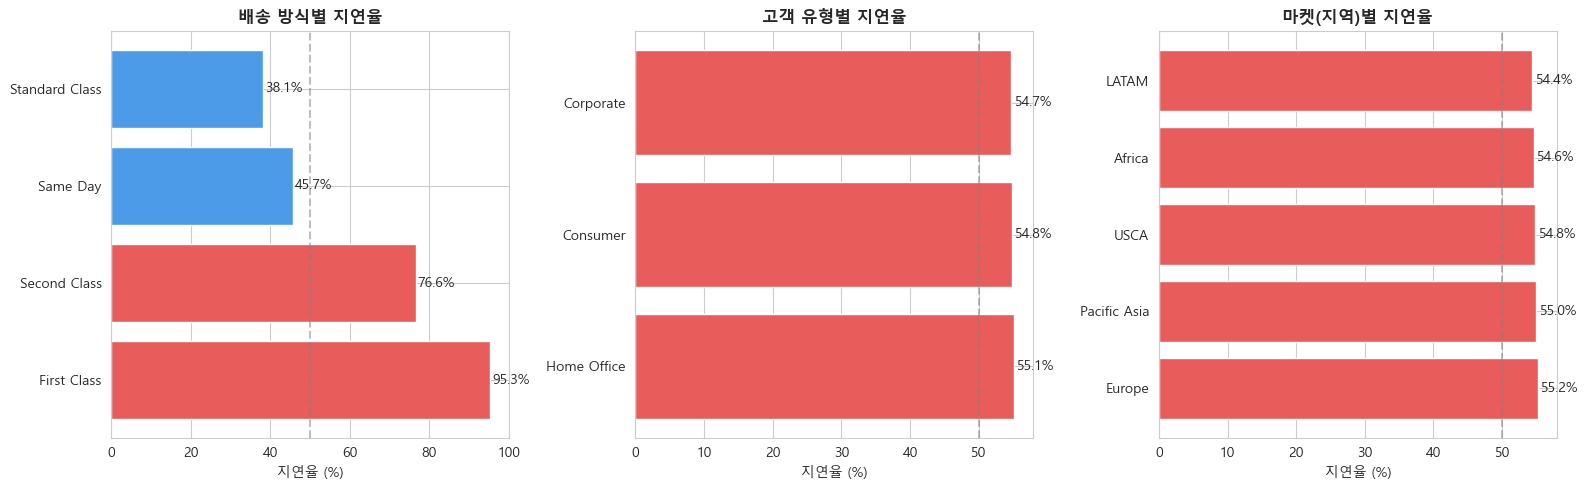

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 배송 방식별 지연율
ship_delay = get_delay_rate(df, 'Shipping Mode')
bar_colors = ['#E85C5C' if v > 50 else '#4C9BE8' for v in ship_delay.values]
axes[0].barh(ship_delay.index, ship_delay.values, color=bar_colors)
axes[0].set_title('배송 방식별 지연율', fontsize=12, fontweight='bold')
axes[0].set_xlabel('지연율 (%)')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% 기준선')
for i, v in enumerate(ship_delay.values):
    axes[0].text(v + 0.5, i, f'{v}%', va='center')

# 고객 유형별 지연율
seg_delay = get_delay_rate(df, 'Customer Segment')
bar_colors2 = ['#E85C5C' if v > 50 else '#4C9BE8' for v in seg_delay.values]
axes[1].barh(seg_delay.index, seg_delay.values, color=bar_colors2)
axes[1].set_title('고객 유형별 지연율', fontsize=12, fontweight='bold')
axes[1].set_xlabel('지연율 (%)')
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(seg_delay.values):
    axes[1].text(v + 0.5, i, f'{v}%', va='center')

# 마켓별 지연율
market_delay = get_delay_rate(df, 'Market')
bar_colors3 = ['#E85C5C' if v > 50 else '#4C9BE8' for v in market_delay.values]
axes[2].barh(market_delay.index, market_delay.values, color=bar_colors3)
axes[2].set_title('마켓(지역)별 지연율', fontsize=12, fontweight='bold')
axes[2].set_xlabel('지연율 (%)')
axes[2].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(market_delay.values):
    axes[2].text(v + 0.5, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

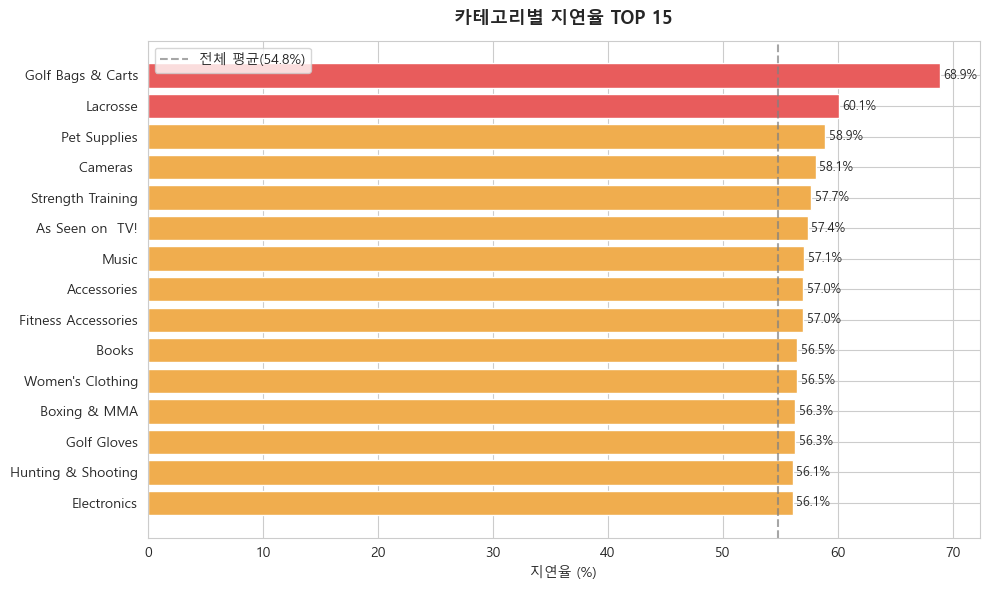

In [10]:
# 카테고리별 지연율 — 상위 15개만 표시
cat_delay = get_delay_rate(df, 'Category Name').head(15)

plt.figure(figsize=(10, 6))
bar_colors = ['#E85C5C' if v > 60 else '#F0AD4E' if v > 50 else '#4C9BE8' for v in cat_delay.values]
plt.barh(cat_delay.index[::-1], cat_delay.values[::-1], color=bar_colors[::-1])
plt.title('카테고리별 지연율 TOP 15', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('지연율 (%)')
plt.axvline(x=54.8, color='gray', linestyle='--', alpha=0.7, label='전체 평균(54.8%)')
plt.legend()
for i, v in enumerate(cat_delay.values[::-1]):
    plt.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. 수치형 변수 분포 확인

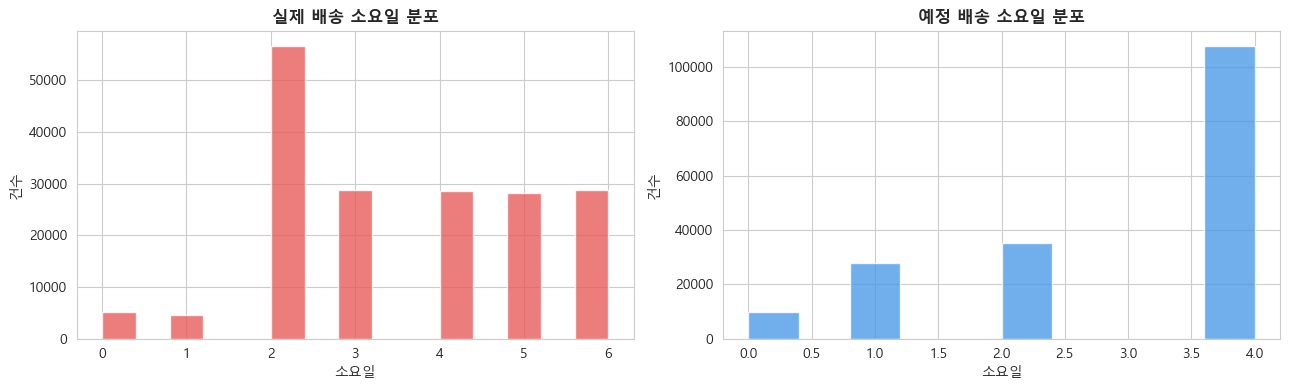

실제 배송 소요일 통계:
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64

예정 배송 소요일 통계:
count    180519.000000
mean          2.931847
std           1.374449
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           4.000000
Name: Days for shipment (scheduled), dtype: float64


In [11]:
# 실제 배송일 vs 예정 배송일 비교 — 핵심 변수
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 실제 배송 소요일 분포
axes[0].hist(df['Days for shipping (real)'], bins=15, color='#E85C5C', alpha=0.8, edgecolor='white')
axes[0].set_title('실제 배송 소요일 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('소요일')
axes[0].set_ylabel('건수')

# 예정 배송 소요일 분포
axes[1].hist(df['Days for shipment (scheduled)'], bins=10, color='#4C9BE8', alpha=0.8, edgecolor='white')
axes[1].set_title('예정 배송 소요일 분포', fontsize=12, fontweight='bold')
axes[1].set_xlabel('소요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.show()

print('실제 배송 소요일 통계:')
print(df['Days for shipping (real)'].describe())
print()
print('예정 배송 소요일 통계:')
print(df['Days for shipment (scheduled)'].describe())

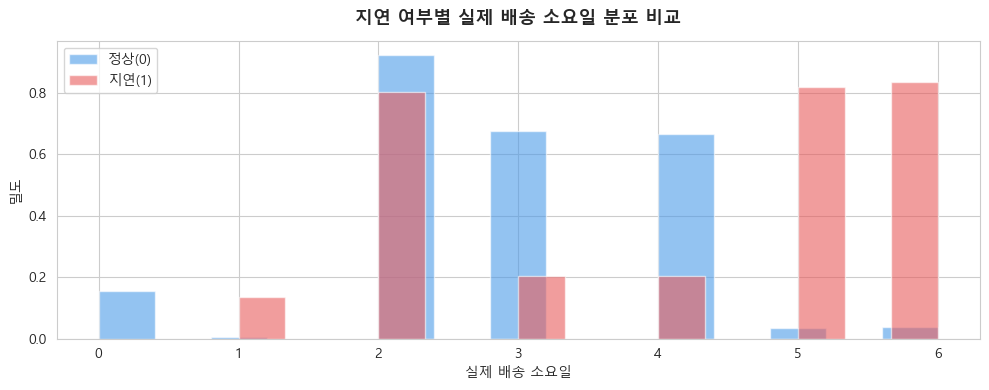

In [12]:
# 지연 여부에 따른 실제 배송 소요일 분포 비교
# → 지연된 주문과 정상 주문 간에 소요일 차이가 있는지 확인
plt.figure(figsize=(10, 4))

df[df['Late_delivery_risk'] == 0]['Days for shipping (real)'].hist(
    bins=15, alpha=0.6, color='#4C9BE8', label='정상(0)', density=True)
df[df['Late_delivery_risk'] == 1]['Days for shipping (real)'].hist(
    bins=15, alpha=0.6, color='#E85C5C', label='지연(1)', density=True)

plt.title('지연 여부별 실제 배송 소요일 분포 비교', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('실제 배송 소요일')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. 상관관계 분석

수치형 변수들 간의 상관관계를 확인하고, 타겟 변수와 관계가 높은 변수를 찾는다.

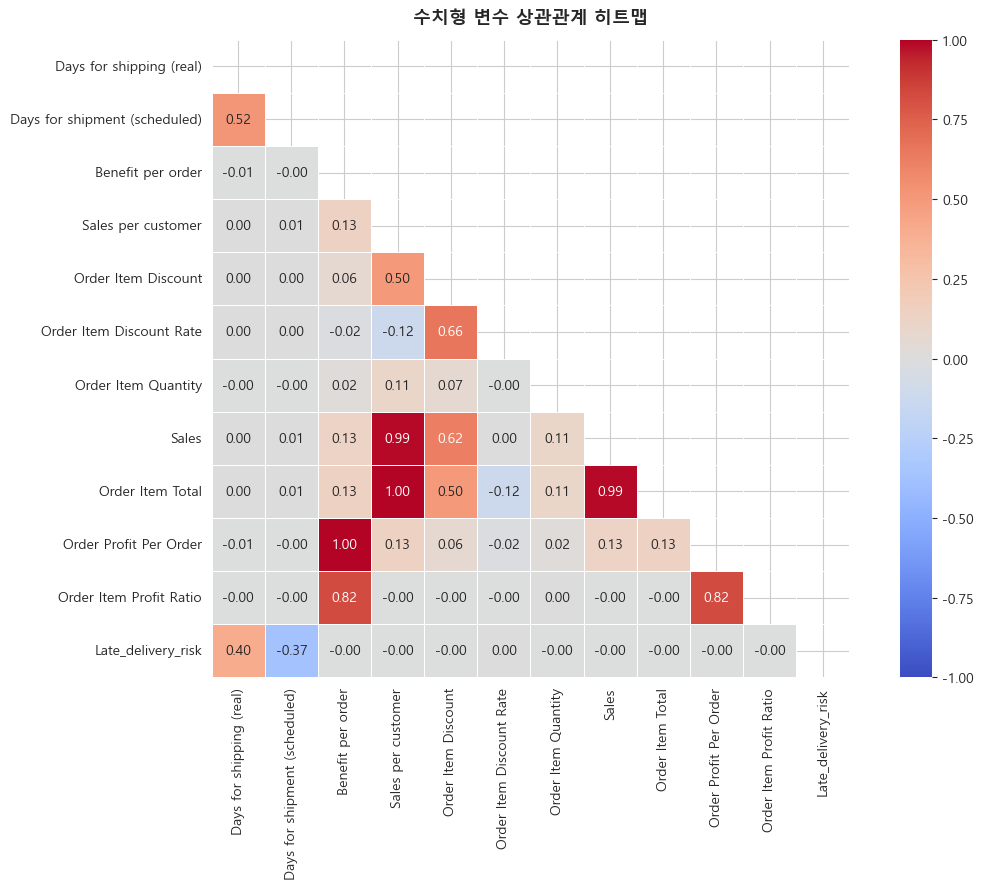

In [13]:
# 분석에 사용할 수치형 컬럼만 선택
# 주의: Days for shipping (real)은 배송 완료 후 확인 가능한 사후 정보다.
# EDA에서는 타겟과의 관계를 확인하되, 모델링 단계에서는 데이터 누수 방지를 위해 제거한다.
num_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Order Item Profit Ratio',
    'Late_delivery_risk'   # 타겟 변수
]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 대각선 위쪽은 가림
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('수치형 변수 상관관계 히트맵', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

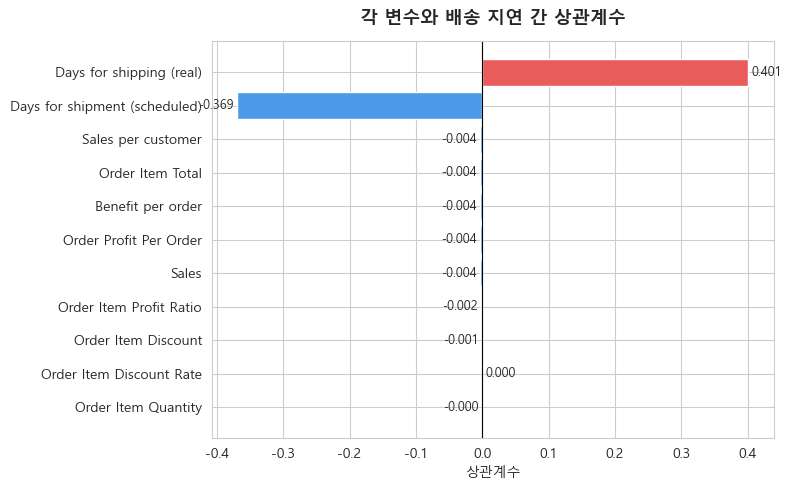

[해석]
Days for shipping (real)이 타겟과 가장 높은 상관관계 → 핵심 피처로 활용 가능


In [14]:
# 타겟 변수(Late_delivery_risk)와의 상관계수만 따로 확인
target_corr = corr_matrix['Late_delivery_risk'].drop('Late_delivery_risk').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
bar_colors = ['#E85C5C' if v > 0 else '#4C9BE8' for v in target_corr.values]
plt.barh(target_corr.index[::-1], target_corr.values[::-1], color=bar_colors[::-1])
plt.title('각 변수와 배송 지연 간 상관계수', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('상관계수')
plt.axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values[::-1]):
    plt.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('[해석]')
print('Days for shipping (real)이 타겟과 가장 높은 상관관계 → 핵심 피처로 활용 가능')

---
## 7. EDA 요약 및 인사이트 정리

In [15]:
print('='*55)
print('         EDA 주요 인사이트 요약')
print('='*55)
print()
print('[1] 전체 지연율이 54.8%로 매우 높음')
print('    → 절반 이상의 주문이 지연 — 구조적인 문제 가능성')
print()

ship_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
print('[2] 배송 방식별 실제 지연율 차이 뚜렷')
for mode, rate in ship_delay.sort_values(ascending=False).items():
    print(f'    - {mode}: {rate:.1f}%')
print('    → First Class / Second Class의 지연율이 높음')
print('    → Standard Class는 주문 수가 많아 운영상 중요하지만, 지연율 자체는 상대적으로 낮음')
print()

print('[3] 실제 배송 소요일은 타겟과 강하게 연결되지만 데이터 누수 변수')
print('    → Days for shipping (real)은 배송 완료 후 확인 가능한 사후 정보')
print('    → 주문 시점 예측 모델에서는 피처에서 제거해야 함')
print()
print('[4] 다음 단계')
print('    - 개인정보 / ID / 이미지 URL 등 불필요 컬럼 제거')
print('    - Delivery Status, Days for shipping (real) 등 누수 컬럼 제거')
print('    - 범주형 변수 One-Hot Encoding')
print('    - 날짜 변수에서 파생 변수 생성 (주문 월, 요일 등)')
print('='*55)


         EDA 주요 인사이트 요약

[1] 전체 지연율이 54.8%로 매우 높음
    → 절반 이상의 주문이 지연 — 구조적인 문제 가능성

[2] 배송 방식별 실제 지연율 차이 뚜렷
    - First Class: 95.3%
    - Second Class: 76.6%
    - Same Day: 45.7%
    - Standard Class: 38.1%
    → First Class / Second Class의 지연율이 높음
    → Standard Class는 주문 수가 많아 운영상 중요하지만, 지연율 자체는 상대적으로 낮음

[3] 실제 배송 소요일은 타겟과 강하게 연결되지만 데이터 누수 변수
    → Days for shipping (real)은 배송 완료 후 확인 가능한 사후 정보
    → 주문 시점 예측 모델에서는 피처에서 제거해야 함

[4] 다음 단계
    - 개인정보 / ID / 이미지 URL 등 불필요 컬럼 제거
    - Delivery Status, Days for shipping (real) 등 누수 컬럼 제거
    - 범주형 변수 One-Hot Encoding
    - 날짜 변수에서 파생 변수 생성 (주문 월, 요일 등)
